In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c, sigma_T, m_p

In [3]:
3e4 * u.Lsun * G * 1e8 / (c**5)

<Quantity 8.2684378e-41 s3 solLum / (kg m2)>

In [4]:
_.si

<Quantity 3.16515799e-14>

In [2]:
M = 1e8*u.Msun
lambda_d = 0.01
eta_d = 0.1 
L_edd = 1.26e38*(M/u.Msun) * u.erg / u.s
Mdot_edd = L_edd/(eta_d*c*c)
Mdot = lambda_d*Mdot_edd
Mdot.to(u.kg/u.s)

<Quantity 1.40193907e+21 kg / s>

In [3]:
# Create disk object
disk = AGNDisk()

# Set required parameters
disk.M = M        # Central black hole mass
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Accretion rate as a fraction of the Eddington limit
#MdotEddFrac = 0.1             # Fraction of Eddington accretion rate



disk.Mdot = Mdot

# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 9, 5000))

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:1105: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [1755, 1955) around index 1855 (R/Rg ≈ 9302.4) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  self.generate(rvals=rvals)


In [4]:
if False:
    # Create disk object
    disk_SuperE = AGNDisk()

    # Set required parameters
    disk_SuperE.M = 1e8 * u.Msun          # Central black hole mass
    disk_SuperE.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

    # Accretion rate as a fraction of the Eddington limit
    MdotEddFrac = 1.3              # Fraction of Eddington accretion rate
    epsilon = 0.1                   # Radiative efficiency (0.1 for Schwarzschild BH)

    kappa = sigma_T / m_p           # Electron scattering opacity
    L_Edd = 4 * np.pi * G * disk_SuperE.M * c / kappa   # Eddington luminosity
    Mdot_Edd = (L_Edd / (epsilon * c**2)).to(u.kg / u.s)  # Eddington accretion rate
    disk_SuperE.Mdot = MdotEddFrac * Mdot_Edd

    # Generate the disk profile
    # rvals can be passed as dimensionless (multiples of Rg) or with units
    # If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
    #df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
    df_super_eddington = disk_SuperE.spacehub_pretab(rvals=np.logspace(1, 9, 500))

In [5]:
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone,grad_T,grad_Sigma,grad_P,grad_P_raw,grad_Sigma_raw
0,1.476625e+12,1.000000e+01,350251.174694,3.207957e-05,3.949894e+06,350896.015509,5.465476e+09,1.917814e+14,175329.256010,612800.237905,Standard,0.360492,0.146820,1.470937,1.470937,0.146820
1,1.482076e+12,1.003692e+01,349786.221583,3.186483e-05,3.928543e+06,351123.520013,5.499332e+09,1.930945e+14,175234.426235,610147.574345,Standard,0.360763,0.141031,1.471481,1.471481,0.141031
2,1.487548e+12,1.007397e+01,349321.187093,3.165436e-05,3.907291e+06,351334.774366,5.533140e+09,1.943984e+14,175147.119632,607452.125654,Standard,0.361300,0.129530,1.472558,1.472558,0.129530
3,1.493039e+12,1.011116e+01,348856.087188,3.144804e-05,3.886139e+06,351529.973864,5.566899e+09,1.956932e+14,175067.227133,604715.286117,Standard,0.361827,0.118178,1.473614,1.473614,0.118178
4,1.498551e+12,1.014849e+01,348390.937290,3.124579e-05,3.865087e+06,351709.312134,5.600610e+09,1.969787e+14,174994.642518,601938.431549,Standard,0.362343,0.106975,1.474648,1.474648,0.106975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.455020e+20,9.853686e+08,1.169843,1.027352e-23,4.724680e-16,6781.512740,1.033176e+20,7.006494e+22,0.002123,1.000000,Self-Reg,0.749928,1.499987,2.999974,2.999974,1.499987
4996,1.460391e+20,9.890063e+08,1.166615,1.016057e-23,4.672738e-16,6781.513065,1.038902e+20,7.045329e+22,0.002111,1.000000,Self-Reg,0.749928,1.499987,2.999974,2.999974,1.499987
4997,1.465783e+20,9.926573e+08,1.163396,1.004887e-23,4.621368e-16,6781.513389,1.044661e+20,7.084379e+22,0.002100,1.000000,Self-Reg,0.749928,1.499987,2.999974,2.999974,1.499987
4998,1.471194e+20,9.963219e+08,1.160185,9.938396e-24,4.570562e-16,6781.513712,1.050451e+20,7.123646e+22,0.002088,1.000000,Self-Reg,0.749928,1.499987,2.999974,2.999974,1.499987


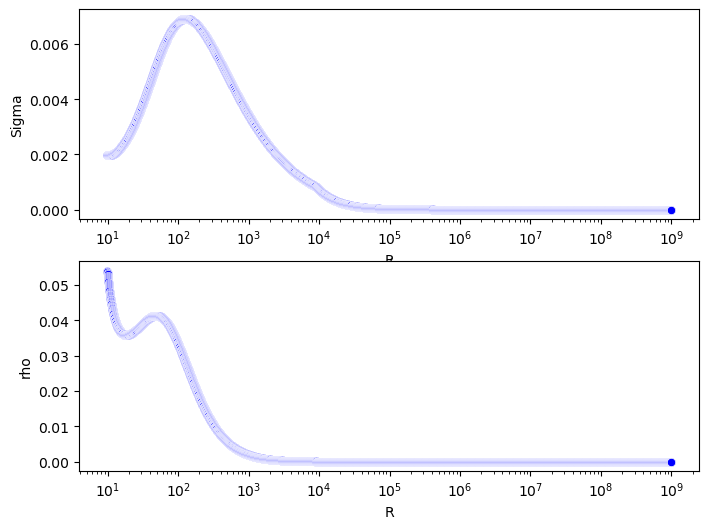

In [8]:
if True:
    fig, axes = plt.subplots(2,1, figsize=(8,6))
    ax = axes.flatten()[0]
    sns.scatterplot(data=df, x="R", y="Sigma", ax=ax, color="blue")
    ax.set_xscale("log")
    ax = axes.flatten()[1]
    sns.scatterplot(data=df, x="R", y="rho", ax=ax, color="blue")
    ax.set_xscale("log")

In [7]:
if False:
    df.to_csv("../../SpaceHub/src/interaction/disk_tab/SG_01Edd.csv", index=False)